In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import robotdatapy as rdp # 1.0.3
import scipy as sp

# plt.style.use('/home/masonbp/computer/python/matplotlib/publication.mplstyle')
SAVE = True
QUICK = False
ADD_ANNOTATIONS = True

# quicker
if QUICK:
    num_pcs = 100
    num_markers = 500
else:
    num_pcs = 3000
    num_markers = 4000

In [2]:
def get_pc(bag_path, topic, child_frame):
    pcd = rdp.data.PointCloudData.from_bag(
        path=bag_path,
        topic=topic,
    )

    marker_data = rdp.data.GeneralData.from_bag(
        path=bag_path,
        topic="/NX01/actual_traj",
        ros_distro='humble',
        time_tol=30.0,
        causal=False
    )

    pc_frame = pcd.msg_header(pcd.t0).frame_id
    print("pc_frame:", pc_frame)

    pd = rdp.data.PoseData.from_bag_tf(
        bag_path,
        parent_frame="map",
        child_frame=child_frame,
        time_tol=30.0
    )

    # Robust point cloud extraction at pcd.tf
    pc = pcd.pointcloud(pcd.tf).get_xyz()
    # if not isinstance(vecs, np.ndarray) or vecs.ndim != 2 or vecs.shape[0] == 0 or vecs.shape[1] != 3:
    #     print(f"[Warning] Empty or invalid point cloud at t = {pcd.tf}. Skipping transform.")
    #     pc = np.zeros((0, 3))
    # else:
    #     pc = rdp.transform.transform(pd.pose(pcd.tf), vecs)

    return pc, pcd, pd, marker_data

def apply_transform(points):
    T_side_view = rdp.transform.xyz_rpy_to_transform([0., 0., 0.], [-85., -0., 0.], degrees=True) @ \
        rdp.transform.xyz_rpy_to_transform([0., 0., 0.,], [0., 0., 80.], degrees=True)
    # T_side_view = np.eye(4)

    # degrees to rotation matrix
    roll = 180
    pitch = 0
    yaw = 0

    rotation_matrix = sp.spatial.transform.Rotation.from_euler('xyz', [roll, pitch, yaw], degrees=True).as_matrix()
    T_world_cam = np.array([
        [1., 0., 0., 60.,],
        [0., -1., 0., 0.,],
        [0., 0., -1., 175.,],
        [0., 0., 0., 1.,]
    ])

    K = np.array([[300, 0., 0.], [0., 300, 0.], [0., 0., 1.]])

    points_cam = rdp.transform.transform(np.linalg.inv(T_world_cam) @ T_side_view, points)
    points_cam = points_cam[points_cam[:,2] > 0.1]
    points_side_view = rdp.camera.xyz_2_pixel(points_cam, K)
    return points_side_view

def plot_pc(pc, pcd, pd, marker_data, bag_path, figure_name):
    import matplotlib.pyplot as plt
    plt.style.use('dark_background')
    t = np.linspace(pcd.t0, pcd.tf, num_pcs)

    pcs = []
    for ti in t:
        vecs = pcd.pointcloud(ti).get_xyz()
        if vecs.ndim != 2 or vecs.shape[0] == 0 or vecs.shape[1] != 3:
            print(f"[Warning] Skipping invalid point cloud at t = {ti}. Shape = {vecs.shape}")
            continue
        pc = vecs
        # pc = rdp.transform.transform(pd.pose(ti), vecs)
        pcs.append(pc)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10), dpi=500)

    if len(pcs) == 0:
        print("[Warning] No valid point clouds found. Skipping point cloud plot.")
        pc = np.zeros((0, 3))  # Fallback
        ax.text(0.5, 0.5, 'No valid point cloud data', transform=ax.transAxes,
                ha='center', va='center', color='white', fontsize=16)
    else:
        pc = np.vstack(pcs)
        ax.plot(pc[:, 0], pc[:, 1], '.', markersize=0.15, alpha=0.2, color='xkcd:white')

        # --- Compute and add a 10 m scale bar ---
        # x_min, x_max = np.min(pc[:, 0]), np.max(pc[:, 0])
        # y_min, y_max = np.min(pc[:, 1]), np.max(pc[:, 1])
        # print("x_min, x_max, y_min, y_max:", x_min, x_max, y_min, y_max)

        # x_pad = 0.05 * (x_max - x_min)
        # y_pad = 0.05 * (y_max - y_min)
        # x_scale_start = x_min + x_pad - 30.0
        # x_scale_end = x_scale_start + 10.0  # 10 meters
        # y_scale = y_max - y_pad + 20.0

        # ax.plot([x_scale_start, x_scale_end], [y_scale, y_scale], color='white', linewidth=1.5)
        # ax.plot([x_scale_start, x_scale_start], [y_scale - 0.5, y_scale + 0.5], color='white', linewidth=0.5)
        # ax.plot([x_scale_end, x_scale_end], [y_scale - 0.5, y_scale + 0.5], color='white', linewidth=0.5)
        # ax.text(x_scale_start, y_scale - 4.5, '10 m', color='white', fontsize=16)

    # --- Plot markers ---
    marker_xyz = []
    marker_colors = []
    for ti in np.linspace(marker_data.t0, marker_data.tf, num_markers):
        position_ros = marker_data.data(ti).pose.position
        color_ros = marker_data.data(ti).color
        mi = np.array([position_ros.x, position_ros.y, position_ros.z])
        marker_xyz.append(rdp.transform.transform(pd.pose(ti), mi))
        marker_colors.append([color_ros.r, color_ros.g, color_ros.b])
    marker_xyz = np.array(marker_xyz)
    marker_colors = np.array(marker_colors)

    for i in range(marker_xyz.shape[0]):
        ax.plot(marker_xyz[i, 0], marker_xyz[i, 1], '.', markersize=1.0, alpha=1.0, color=marker_colors[i])

    # --- Annotations ---
    if ADD_ANNOTATIONS and len(marker_xyz) > 0:
        markersize = 15.0
        bbox_props = dict(facecolor='white', boxstyle='round,pad=0.1')
        ax.plot([marker_xyz[0, 0]], [marker_xyz[0, 1]], '.', markersize=markersize, color='xkcd:red')
        ax.plot([marker_xyz[-1, 0]], [marker_xyz[-1, 1]], '.', markersize=markersize, color='xkcd:blue')
        ax.text(marker_xyz[0, 0] - 30.0, marker_xyz[0, 1] - 1, 'Start', color='red', fontsize=16, bbox=bbox_props)
        ax.text(marker_xyz[-1, 0] + 5.0, marker_xyz[-1, 1] - 1, 'Goal', color='blue', fontsize=16, bbox=bbox_props)

    ax.set_aspect('equal')
    ax.axis('off')

    if SAVE:
        folder_path = bag_path[:bag_path.rfind('/')]
        plt.savefig(folder_path + figure_name, bbox_inches='tight')

    return pc, marker_xyz, marker_colors

def plot_with_angle(pc, marker_xyz, marker_colors, bag_path, figure_name):
    fig, ax = plt.subplots(figsize=(10, 10), dpi=500)

    # Apply side view transform if point cloud is not empty
    if pc.shape[0] > 0:
        pc_side_view = apply_transform(pc)
        ax.plot(pc_side_view[:, 0], -pc_side_view[:, 1], '.', markersize=0.15, alpha=0.2, color='xkcd:white')
    else:
        print("[Warning] No point cloud data for side view. Skipping point cloud plot.")
        ax.text(0.5, 0.5, 'No point cloud', transform=ax.transAxes,
                ha='center', va='center', color='white', fontsize=16)

    # Apply side view transform to marker data if available
    if marker_xyz.shape[0] > 0:
        marker_xyz_side_view = apply_transform(marker_xyz)

        for i in range(marker_xyz_side_view.shape[0]):
            ax.plot(marker_xyz_side_view[i, 0], -marker_xyz_side_view[i, 1], '.',
                    markersize=1.0, alpha=1.0, color=marker_colors[i])

        if ADD_ANNOTATIONS:
            markersize = 10.0
            bbox = dict(facecolor='white', boxstyle='round,pad=0.1')
            # Plot start and goal markers
            ax.plot([marker_xyz_side_view[0, 0]], [-marker_xyz_side_view[0, 1]], '.', markersize=markersize, color='xkcd:red')
            ax.plot([marker_xyz_side_view[-1, 0]], [-marker_xyz_side_view[-1, 1]], '.', markersize=markersize, color='xkcd:blue')
            # Add labels
            ax.text(marker_xyz_side_view[0, 0] - 2, -marker_xyz_side_view[0, 1] + 3,
                    'Start', color='red', fontsize=16, bbox=bbox)
            ax.text(marker_xyz_side_view[-1, 0] - 3, -marker_xyz_side_view[-1, 1] - 5,
                    'Goal', color='blue', fontsize=16, bbox=bbox)
    else:
        print("[Warning] No marker data for side view.")

    ax.set_aspect('equal')
    ax.axis('off')

    if SAVE:
        folder_path = bag_path[:bag_path.rfind('/')]
        plt.savefig(folder_path + figure_name, bbox_inches='tight')


pc_frame: map
[Warning] Skipping invalid point cloud at t = 1758736697.6973357. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736697.7282808. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736697.7592256. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736697.7901707. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736697.8211157. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736697.8520606. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736697.8830056. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736697.9139507. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736697.9448957. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736697.9758406. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736698.0067856. Shape = (0,)
[Warning] Skipping invalid point cloud at t = 1758736698.0377307. Shape = (0,)
[Warning] Skipping invalid point cloud

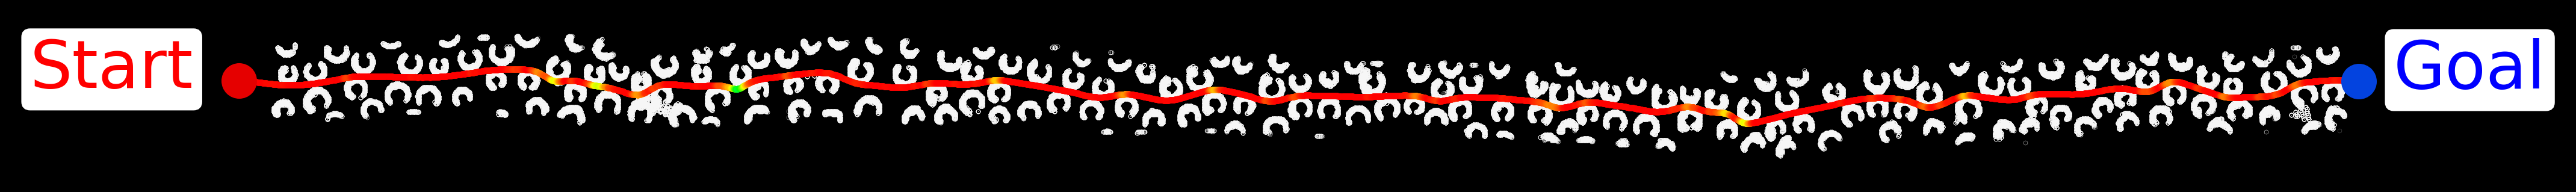

In [3]:
# plot the point cloud data
# topic = "/NX01/mid360_PointCloud2"
topic = "/NX01/occupancy_grid"
bag_num = "num_1"

bag_path = f"/media/kkondo/kota_elements/sando/static/hard_forest/unconstrained/bags/sando/{bag_num}"
pc, pcd, pd, marker_data = get_pc(bag_path, topic, child_frame="NX01/NX01_livox")

paper_path = "/home/kkondo/paper_writing/sando_paper/sando_paper/figures/hard_forest/"
pc, marker_xyz, marker_colors = plot_pc(pc, pcd, pd, marker_data, paper_path, f"/static_{bag_num}_overhead_pc.png")
# plot_with_angle(pc, marker_xyz, marker_colors, paper_path, f"/static_{bag_num}_side_view_pc.png")

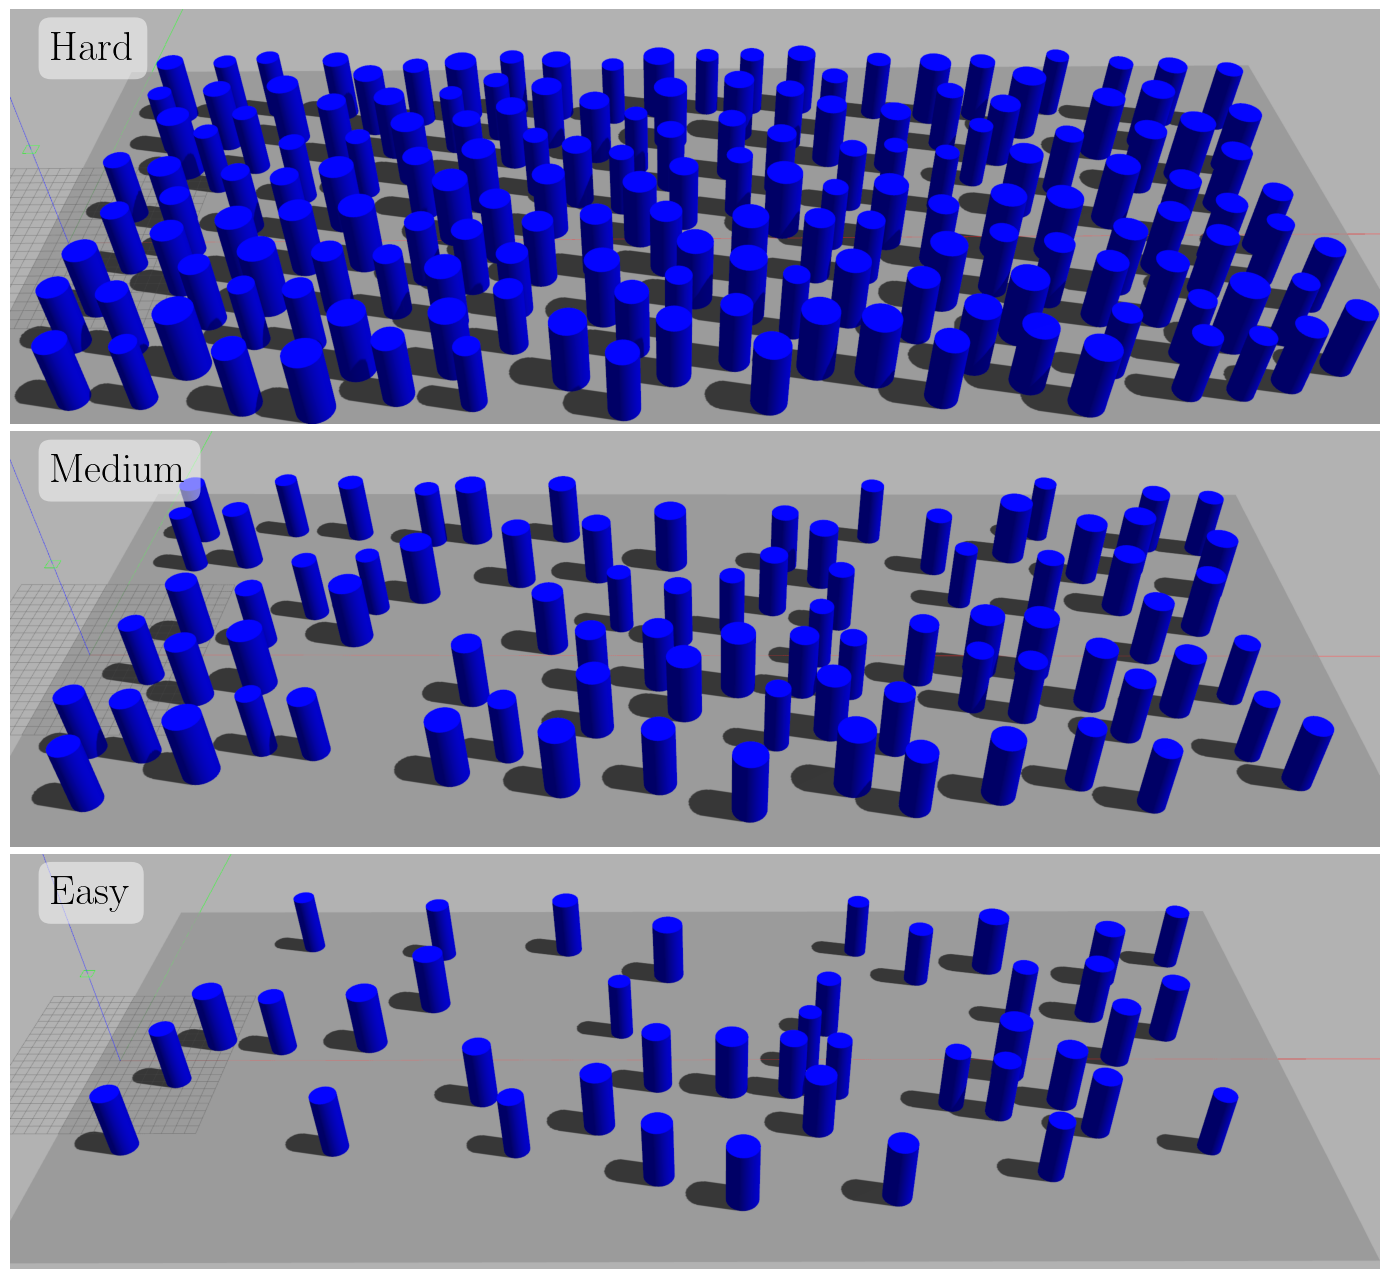

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as font_manager

# font
font = font_manager.FontProperties()
font.set_family('serif')
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"
font.set_size(60)

folder = "/home/kkondo/code/dynus_ws/src/sando/paper_imgs"
save_folder = "/home/kkondo/paper_writing/SANDO_v3/figures/sim/static_benchmark"

# ---- Crop parameters (pixels): top, bottom, left, right ----
CROP = {
    'hard_forest':   dict(top=300, bottom=300, left=500, right=150),
    'medium_forest': dict(top=300, bottom=300, left=400, right=250),
    'easy_forest':   dict(top=300, bottom=300, left=400, right=250),
}

def load_and_crop(name):
    img = plt.imread(f"{folder}/{name}.png")
    c = CROP[name]
    h, w = img.shape[:2]
    return img[c['top']: h - c['bottom'] if c['bottom'] else h,
               c['left']: w - c['right']  if c['right']  else w]

hard   = load_and_crop('hard_forest')
medium = load_and_crop('medium_forest')
easy   = load_and_crop('easy_forest')

# ---- Stack vertically ----
fig, axes = plt.subplots(3, 1, figsize=(14, 14 * 3 * hard.shape[0] / hard.shape[1]))

labels = ['Hard', 'Medium', 'Easy']
for ax, img, label in zip(axes, [hard, medium, easy], labels):
    ax.imshow(img)
    ax.text(0.03, 0.95, label, transform=ax.transAxes,
            fontsize=30, va='top', ha='left', color='black',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.3'))
    ax.axis('off')

plt.tight_layout(pad=0.5)
plt.savefig(f"{save_folder}/stacked_forests.png", bbox_inches='tight', dpi=150)
plt.show()


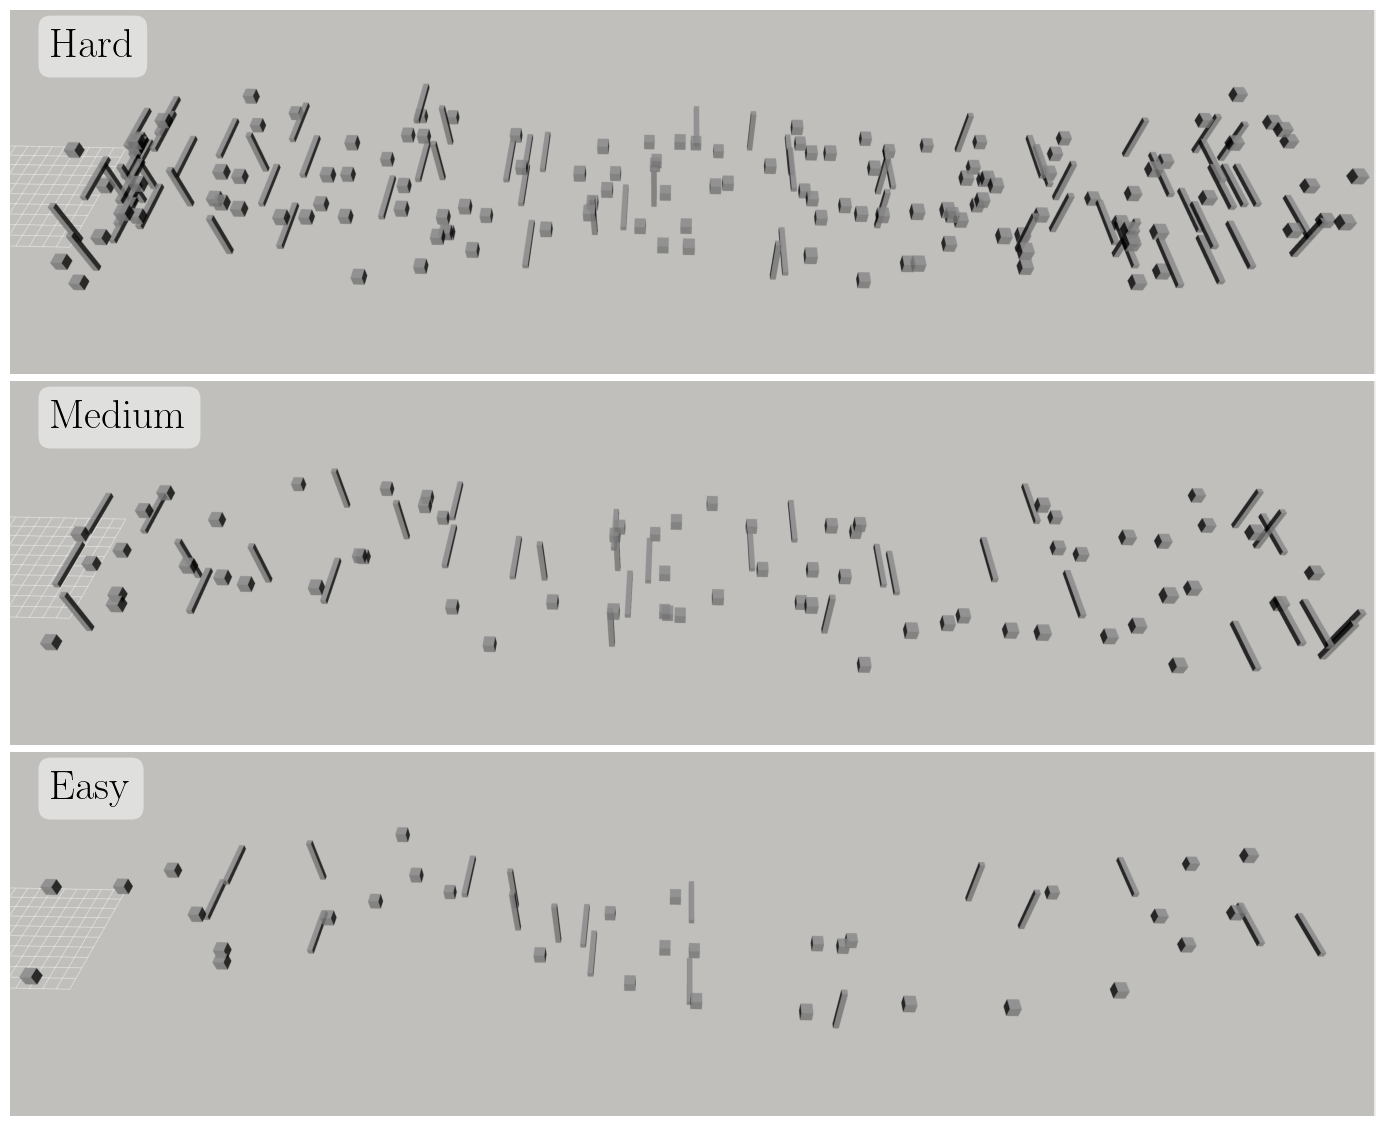

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as font_manager

# font
font = font_manager.FontProperties()
font.set_family('serif')
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"
font.set_size(60)

folder = "/home/kkondo/code/dynus_ws/src/sando/paper_imgs"
save_folder = "/home/kkondo/paper_writing/SANDO_v3/figures/sim/dynamic_benchmark"

# ---- Crop parameters (pixels): top, bottom, left, right ----
CROP = {
    'dynamic_hard':   dict(top=600, bottom=600, left=220, right=20),
    'dynamic_medium': dict(top=600, bottom=600, left=220, right=20),
    'dynamic_easy':   dict(top=600, bottom=600, left=220, right=20),
}

def load_and_crop(name):
    img = plt.imread(f"{folder}/{name}.png")
    c = CROP[name]
    h, w = img.shape[:2]
    return img[c['top']: h - c['bottom'] if c['bottom'] else h,
               c['left']: w - c['right']  if c['right']  else w]

hard   = load_and_crop('dynamic_hard')
medium = load_and_crop('dynamic_medium')
easy   = load_and_crop('dynamic_easy')

# ---- Stack vertically ----
fig, axes = plt.subplots(3, 1, figsize=(14, 14 * 3 * hard.shape[0] / hard.shape[1]))

labels = ['Hard', 'Medium', 'Easy']
for ax, img, label in zip(axes, [hard, medium, easy], labels):
    ax.imshow(img)
    ax.text(0.03, 0.95, label, transform=ax.transAxes,
            fontsize=30, va='top', ha='left', color='black',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.3'))
    ax.axis('off')

plt.tight_layout(pad=0.5)
plt.savefig(f"{save_folder}/stacked_dynamic_env.png", bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import matplotlib.patches as patches
import numpy as np
from PIL import Image as PILImage

# font
font = font_manager.FontProperties()
font.set_family('serif')
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"

save_folder = "/home/kkondo/paper_writing/SANDO_v3/figures/sim/static_benchmark"
src_img_path = "/home/kkondo/code/dynus_ws/src/sando/benchmark_data/visualization_bags/static_benchmark/static_hard/static_hard_rviz.png"

img = plt.imread(src_img_path)
h, w = img.shape[:2]
print(f"Full image size: {w}x{h}")

# ---- Crop parameters (pixels relative to the FULL original image) ----
# top/bottom/left/right = how many px to trim from each edge of the full image
CAM_CROP = dict(top=260, bottom=250, left=5, right=2180)   # camera panel (left half)
SIM_CROP = dict(top=500, bottom=300, left=1685, right=50)   # sim panel (right half)

# Overlay settings
INSET_SCALE  = 0.35   # camera inset width as fraction of sim view width
INSET_MARGIN = 20     # px margin from the right edge (in sim-view coords)
FRAME_LW     = 4      # white frame line width (points)
CAM_ALPHA    = 0.6    # camera inset opacity

# ---- Crop helper ----
def crop(im, c):
    ch, cw = im.shape[:2]
    return im[c['top']: ch - c['bottom'] if c['bottom'] else ch,
              c['left']: cw - c['right']  if c['right']  else cw]

cam = crop(img, CAM_CROP)
sim = crop(img, SIM_CROP)
print(f"Camera view: {cam.shape[1]}x{cam.shape[0]}")
print(f"Simulation view: {sim.shape[1]}x{sim.shape[0]}")

# ---- Resize camera inset ----
sim_h, sim_w = sim.shape[:2]
inset_w = int(sim_w * INSET_SCALE)
inset_h = int(inset_w * cam.shape[0] / cam.shape[1])

cam_uint8 = (np.clip(cam, 0, 1) * 255).astype(np.uint8)
cam_resized = np.array(PILImage.fromarray(cam_uint8).resize((inset_w, inset_h), PILImage.LANCZOS)) / 255.0

# ---- Plot (half-size figure) ----
fig_w = 7
fig_h = fig_w * sim_h / sim_w

fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h), dpi=150)
ax.imshow(sim)   # imshow sets ylim so y=0 is at top; do NOT override with set_ylim

# Inset position: right-center
# axes y=0 is bottom, y=1 is top; since image y=0 is at top of axes, subtract from 1
ix = sim_w - inset_w - INSET_MARGIN        # left edge in image px
iy = (sim_h - inset_h) // 2               # top edge in image px (vertically centered)
ax_inset = ax.inset_axes(
    [ix / sim_w, 1 - (iy + inset_h) / sim_h, inset_w / sim_w, inset_h / sim_h]
)
ax_inset.imshow(cam_resized, alpha=CAM_ALPHA)
ax_inset.axis('off')

# White border as a Rectangle in data (image pixel) coords
rect = patches.Rectangle(
    (ix, iy), inset_w, inset_h,
    linewidth=FRAME_LW, edgecolor='white', facecolor='none',
    transform=ax.transData, zorder=10
)
ax.add_patch(rect)

ax.axis('off')
plt.tight_layout(pad=0)

if SAVE:
    plt.savefig(f"{save_folder}/static_rviz.png", bbox_inches='tight', dpi=150)
    print(f"Saved to {save_folder}/static_rviz.png")

plt.show()


Image 1 size: 3370x1413
Image 2 size: 3370x1413
Camera view: 1185x903
Sim 1: 2125x1003
Sim 2: 2145x903
Saved to /home/kkondo/paper_writing/SANDO_v3/figures/sim/dynamic_benchmark/dynamic_rviz.png


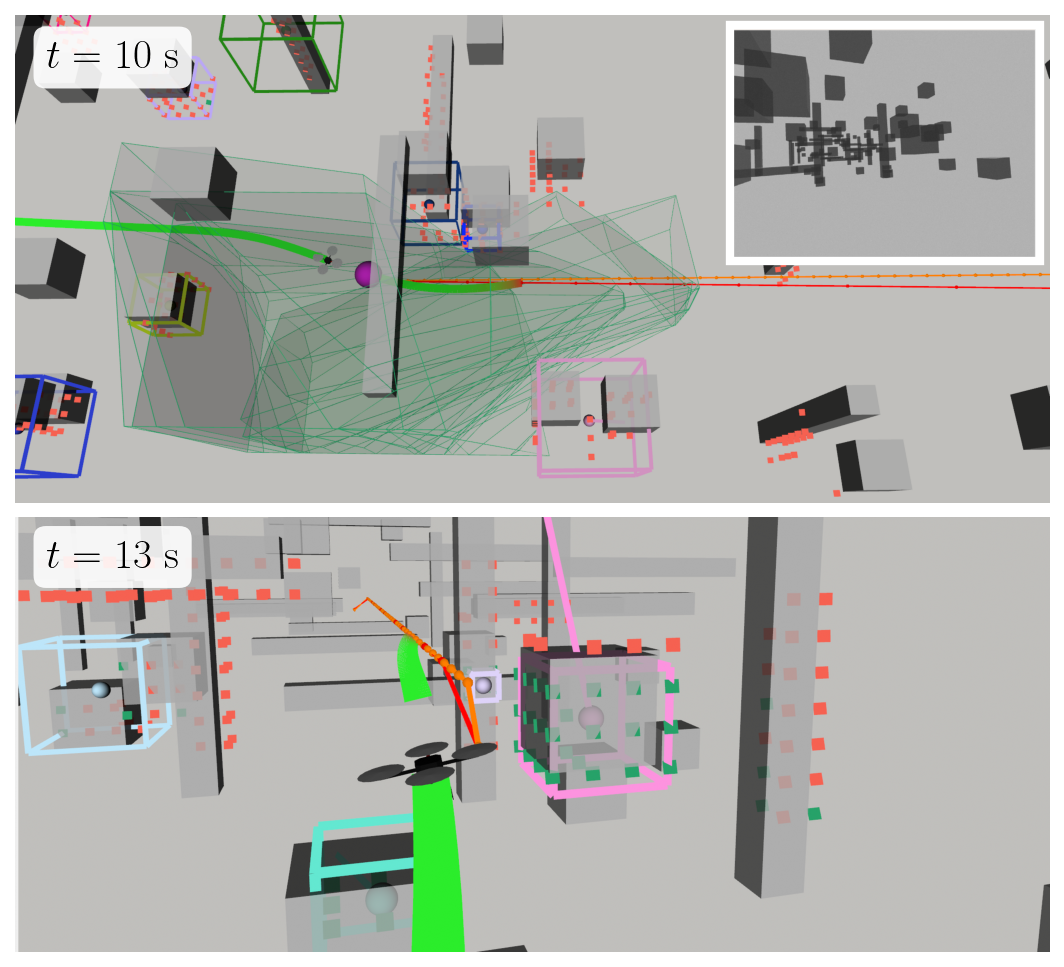

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import matplotlib.patches as patches
import numpy as np
from PIL import Image as PILImage

# font
font = font_manager.FontProperties()
font.set_family('serif')
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"

save_folder = "/home/kkondo/paper_writing/SANDO_v3/figures/sim/dynamic_benchmark"
src_img_path  = "/home/kkondo/code/dynus_ws/src/sando/benchmark_data/visualization_bags/unknown_dynamic/hard/unknown_dynamic_hard_rviz.png"
src_img2_path = "/home/kkondo/code/dynus_ws/src/sando/benchmark_data/visualization_bags/unknown_dynamic/hard/unknown_dynamic_hard_rviz2.png"

img  = plt.imread(src_img_path)
img2 = plt.imread(src_img2_path)
print(f"Image 1 size: {img.shape[1]}x{img.shape[0]}")
print(f"Image 2 size: {img2.shape[1]}x{img2.shape[0]}")

# ---- Crop parameters (pixels relative to the FULL original image) ----
CAM_CROP  = dict(top=260, bottom=250, left=5, right=2180)    # camera panel (left half)
SIM_CROP  = dict(top=200, bottom=210, left=1220, right=25)   # sim panel - image 1
SIM2_CROP = dict(top=400, bottom=110, left=1200, right=25)   # sim panel - image 2

# Overlay settings
INSET_SCALE  = 0.3    # camera inset width as fraction of sim view width
INSET_MARGIN = 20     # px margin from top-right corner (in sim-view coords)
FRAME_LW     = 4      # white frame line width (points)
CAM_ALPHA    = 1   # camera inset opacity
GAP          = 0.03   # gap between the two images (fraction of figure height)

# ---- Crop helper ----
def crop(im, c):
    ch, cw = im.shape[:2]
    return im[c['top']: ch - c['bottom'] if c['bottom'] else ch,
              c['left']: cw - c['right']  if c['right']  else cw]

cam  = crop(img,  CAM_CROP)
sim  = crop(img,  SIM_CROP)
sim2 = crop(img2, SIM2_CROP)
print(f"Camera view: {cam.shape[1]}x{cam.shape[0]}")
print(f"Sim 1: {sim.shape[1]}x{sim.shape[0]}")
print(f"Sim 2: {sim2.shape[1]}x{sim2.shape[0]}")

# ---- Resize camera inset ----
sim_h, sim_w = sim.shape[:2]
inset_w = int(sim_w * INSET_SCALE)
inset_h = int(inset_w * cam.shape[0] / cam.shape[1])

cam_uint8 = (np.clip(cam, 0, 1) * 255).astype(np.uint8)
cam_resized = np.array(PILImage.fromarray(cam_uint8).resize((inset_w, inset_h), PILImage.LANCZOS)) / 255.0

# Resize sim2 to match sim width
sim2_h, sim2_w = sim2.shape[:2]
new_sim2_w = sim_w
new_sim2_h = int(new_sim2_w * sim2_h / sim2_w)
sim2_uint8 = (np.clip(sim2, 0, 1) * 255).astype(np.uint8)
sim2_resized = np.array(PILImage.fromarray(sim2_uint8).resize((new_sim2_w, new_sim2_h), PILImage.LANCZOS)) / 255.0

# ---- Plot: two rows with a small gap ----
fig_w = 7
fig_h = fig_w * (sim_h + new_sim2_h) / sim_w

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_w, fig_h), dpi=150,
                                gridspec_kw={'height_ratios': [sim_h, new_sim2_h]})
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=GAP)

ax1.imshow(sim)

# Camera inset: top-right corner of ax1
ix = sim_w - inset_w - INSET_MARGIN
iy = INSET_MARGIN
ax_inset = ax1.inset_axes(
    [ix / sim_w, 1 - (iy + inset_h) / sim_h, inset_w / sim_w, inset_h / sim_h]
)
ax_inset.imshow(cam_resized, alpha=CAM_ALPHA)
ax_inset.axis('off')

rect = patches.Rectangle(
    (ix, iy), inset_w, inset_h,
    linewidth=FRAME_LW, edgecolor='white', facecolor='none',
    transform=ax1.transData, zorder=10
)
ax1.add_patch(rect)

label_kw = dict(transform=ax1.transAxes, fontsize=20, va='top', ha='left', color='black',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.3'))
ax1.text(0.03, 0.95, r'$t = 10$ s', **label_kw)
ax1.axis('off')

ax2.imshow(sim2_resized)
ax2.text(0.03, 0.95, r'$t = 13$ s', transform=ax2.transAxes,
         fontsize=20, va='top', ha='left', color='black',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.3'))
ax2.axis('off')

if SAVE:
    plt.savefig(f"{save_folder}/dynamic_rviz.png", bbox_inches='tight', dpi=150)
    print(f"Saved to {save_folder}/dynamic_rviz.png")

plt.show()


Sim image:    3840x2160
Camera image: 1440x2560
Sim cropped:    3640x1760
Camera cropped: 1440x2560
Saved to /home/kkondo/paper_writing/SANDO_v3/figures/hardware/dynamic/test10/test10_paper_ready.png


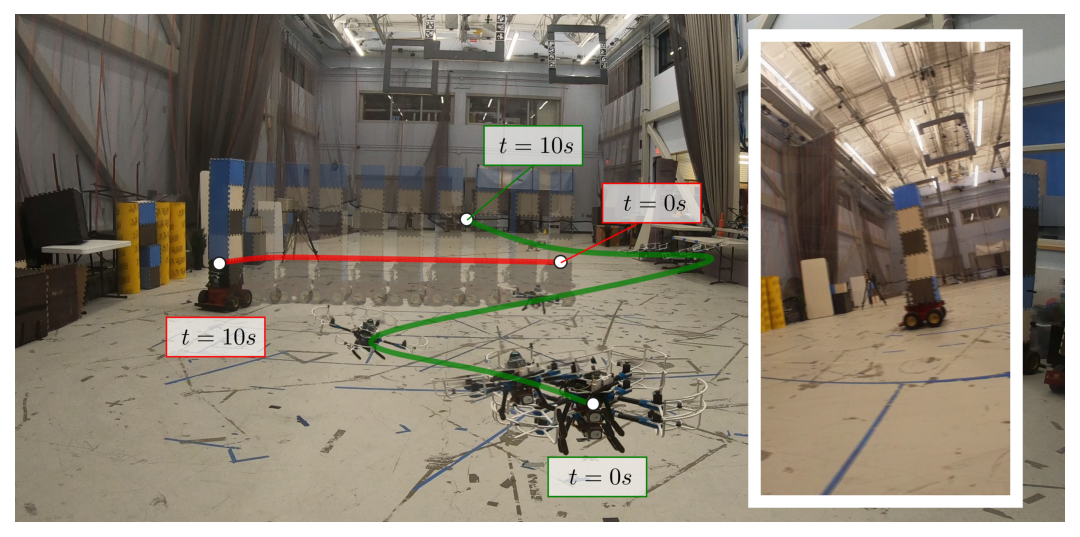

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import matplotlib.patches as patches
import numpy as np
from PIL import Image as PILImage

# font
font = font_manager.FontProperties()
font.set_family('serif')
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"

folder      = "/home/kkondo/paper_writing/SANDO_v3/figures/hardware/dynamic/test10"
sim_path    = f"{folder}/d_test10_composite_annotated.png"
cam_path    = f"{folder}/snapshot_2min.png"

sim_full = plt.imread(sim_path)
cam_full = plt.imread(cam_path)
print(f"Sim image:    {sim_full.shape[1]}x{sim_full.shape[0]}")
print(f"Camera image: {cam_full.shape[1]}x{cam_full.shape[0]}")

# ---- Crop parameters (pixels relative to the full image) ----
SIM_CROP = dict(top=400, bottom=0, left=200, right=0)   # sim (composite)
CAM_CROP = dict(top=0, bottom=0, left=0, right=0)   # camera (snapshot)

# Overlay settings
INSET_SCALE  = 0.25   # camera inset width as fraction of sim view width
INSET_OFFSET_X = 150  # extra px to shift inset left from the right edge
INSET_MARGIN = 20     # base px margin from the right edge
FRAME_LW     = 6      # white frame line width (points)
CAM_ALPHA    = 0.95   # camera inset opacity

# ---- Crop helper ----
def crop(im, c):
    ch, cw = im.shape[:2]
    return im[c['top']: ch - c['bottom'] if c['bottom'] else ch,
              c['left']: cw - c['right']  if c['right']  else cw]

sim = crop(sim_full, SIM_CROP)
cam = crop(cam_full, CAM_CROP)
print(f"Sim cropped:    {sim.shape[1]}x{sim.shape[0]}")
print(f"Camera cropped: {cam.shape[1]}x{cam.shape[0]}")

# ---- Resize camera inset ----
sim_h, sim_w = sim.shape[:2]
inset_w = int(sim_w * INSET_SCALE)
inset_h = int(inset_w * cam.shape[0] / cam.shape[1])

cam_uint8 = (np.clip(cam, 0, 1) * 255).astype(np.uint8)
cam_resized = np.array(PILImage.fromarray(cam_uint8).resize((inset_w, inset_h), PILImage.LANCZOS)) / 255.0

# ---- Plot ----
fig_w = 7
fig_h = fig_w * sim_h / sim_w

fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h), dpi=150)
ax.imshow(sim)

# Camera inset: right side, vertically centered
# Increase INSET_OFFSET_X to move further left
ix = sim_w - inset_w - INSET_MARGIN - INSET_OFFSET_X   # left edge in image px
iy = (sim_h - inset_h) // 2                             # vertically centered
ax_inset = ax.inset_axes(
    [ix / sim_w, 1 - (iy + inset_h) / sim_h, inset_w / sim_w, inset_h / sim_h]
)
ax_inset.imshow(cam_resized, alpha=CAM_ALPHA)
ax_inset.axis('off')

rect = patches.Rectangle(
    (ix, iy), inset_w, inset_h,
    linewidth=FRAME_LW, edgecolor='white', facecolor='none',
    transform=ax.transData, zorder=10
)
ax.add_patch(rect)

ax.axis('off')
plt.tight_layout(pad=0)

if SAVE:
    out_path = f"{folder}/test10_paper_ready.png"
    plt.savefig(out_path, bbox_inches='tight', dpi=150)
    print(f"Saved to {out_path}")

plt.show()


Sim image:    3840x2160
Camera image: 1440x2560
Sim cropped:    3640x1760
Camera cropped: 1440x2560
Saved to /home/kkondo/paper_writing/SANDO_v3/figures/hardware/dynamic/test16/test16_paper_ready.png


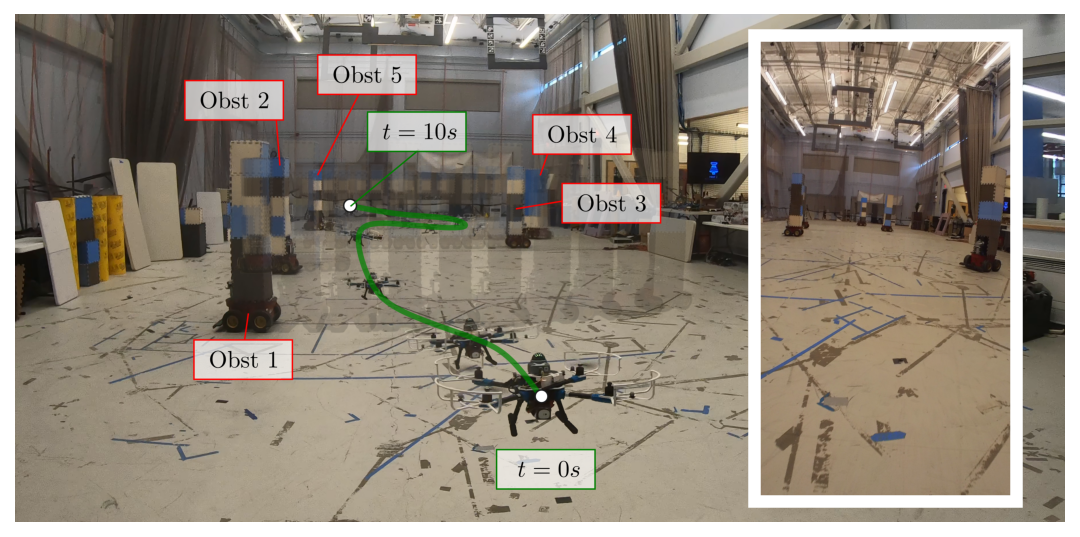

In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import matplotlib.patches as patches
import numpy as np
from PIL import Image as PILImage

# font
font = font_manager.FontProperties()
font.set_family('serif')
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"

folder      = "/home/kkondo/paper_writing/SANDO_v3/figures/hardware/dynamic/test16"
sim_path    = f"{folder}/d_test16_composite_annotated.png"
cam_path    = f"{folder}/snapshot_1min15s.png"

sim_full = plt.imread(sim_path)
cam_full = plt.imread(cam_path)
print(f"Sim image:    {sim_full.shape[1]}x{sim_full.shape[0]}")
print(f"Camera image: {cam_full.shape[1]}x{cam_full.shape[0]}")

# ---- Crop parameters (pixels relative to the full image) ----
SIM_CROP = dict(top=400, bottom=0, left=200, right=0)   # sim (composite)
CAM_CROP = dict(top=0, bottom=0, left=0, right=0)   # camera (snapshot)

# Overlay settings
INSET_SCALE    = 0.25   # camera inset width as fraction of sim view width
INSET_OFFSET_X = 150    # extra px to shift inset left from the right edge
INSET_MARGIN   = 20     # base px margin from the right edge
FRAME_LW       = 6      # white frame line width (points)
CAM_ALPHA      = 0.95   # camera inset opacity

# ---- Crop helper ----
def crop(im, c):
    ch, cw = im.shape[:2]
    return im[c['top']: ch - c['bottom'] if c['bottom'] else ch,
              c['left']: cw - c['right']  if c['right']  else cw]

sim = crop(sim_full, SIM_CROP)
cam = crop(cam_full, CAM_CROP)
print(f"Sim cropped:    {sim.shape[1]}x{sim.shape[0]}")
print(f"Camera cropped: {cam.shape[1]}x{cam.shape[0]}")

# ---- Resize camera inset ----
sim_h, sim_w = sim.shape[:2]
inset_w = int(sim_w * INSET_SCALE)
inset_h = int(inset_w * cam.shape[0] / cam.shape[1])

cam_uint8 = (np.clip(cam, 0, 1) * 255).astype(np.uint8)
cam_resized = np.array(PILImage.fromarray(cam_uint8).resize((inset_w, inset_h), PILImage.LANCZOS)) / 255.0

# ---- Plot ----
fig_w = 7
fig_h = fig_w * sim_h / sim_w

fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h), dpi=150)
ax.imshow(sim)

# Camera inset: right side, vertically centered
# Increase INSET_OFFSET_X to move further left
ix = sim_w - inset_w - INSET_MARGIN - INSET_OFFSET_X   # left edge in image px
iy = (sim_h - inset_h) // 2                             # vertically centered
ax_inset = ax.inset_axes(
    [ix / sim_w, 1 - (iy + inset_h) / sim_h, inset_w / sim_w, inset_h / sim_h]
)
ax_inset.imshow(cam_resized, alpha=CAM_ALPHA)
ax_inset.axis('off')

rect = patches.Rectangle(
    (ix, iy), inset_w, inset_h,
    linewidth=FRAME_LW, edgecolor='white', facecolor='none',
    transform=ax.transData, zorder=10
)
ax.add_patch(rect)

ax.axis('off')
plt.tight_layout(pad=0)

if SAVE:
    out_path = f"{folder}/test16_paper_ready.png"
    plt.savefig(out_path, bbox_inches='tight', dpi=150)
    print(f"Saved to {out_path}")

plt.show()


Sim image:    3840x2160
Camera image: 1440x2560
RViz image:   3370x1413
Sim cropped:    3540x1710
Camera cropped: 1440x2560
RViz cropped:   2070x1013
Saved to /home/kkondo/paper_writing/SANDO_v3/figures/hardware/dynamic/test18/test18_paper_ready.png


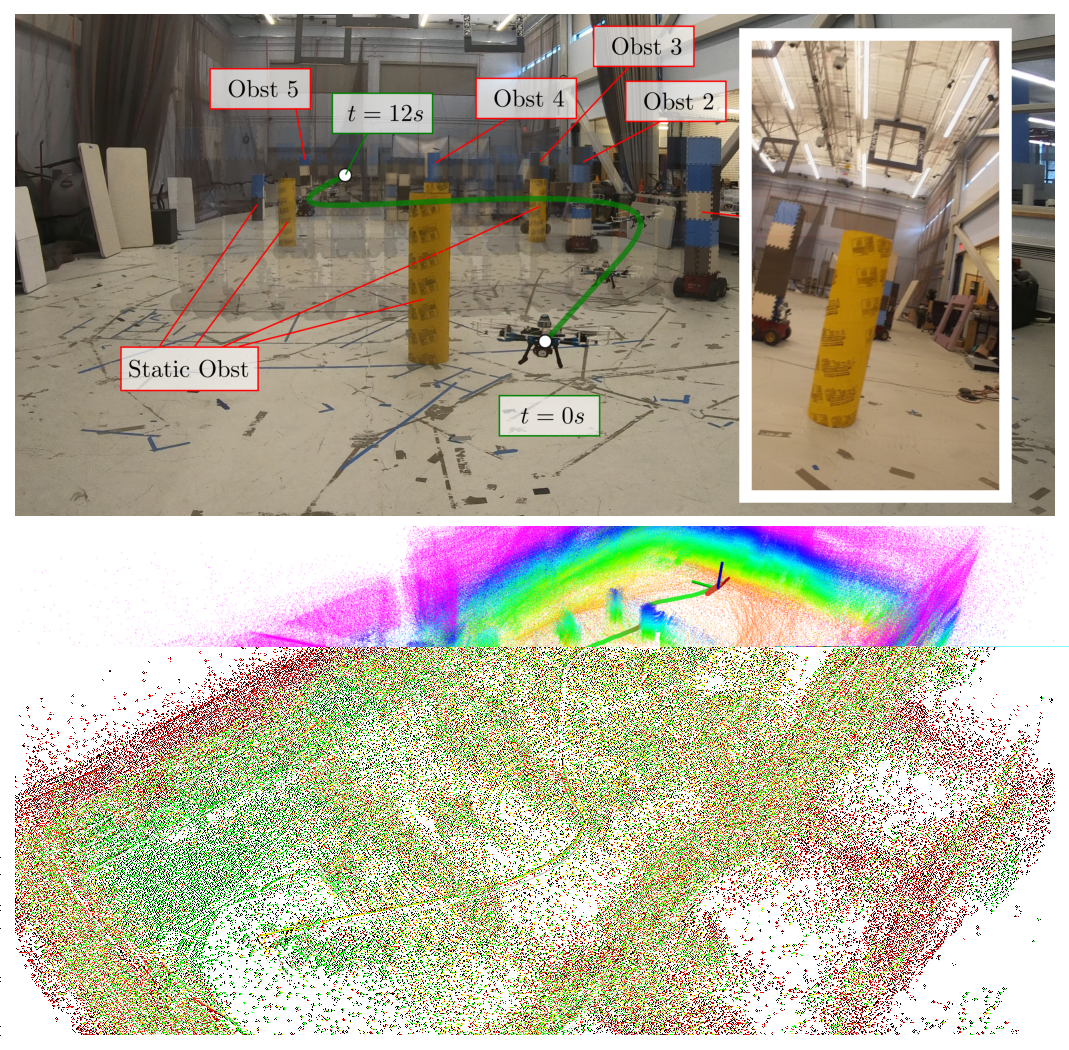

In [15]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import matplotlib.patches as patches
import numpy as np
from PIL import Image as PILImage

# font
font = font_manager.FontProperties()
font.set_family('serif')
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"

folder   = "/home/kkondo/paper_writing/SANDO_v3/figures/hardware/dynamic/test18"
sim_path  = f"{folder}/d_test18_composite_annotated.png"
cam_path  = f"{folder}/snapshot_31s.png"
rviz_path = f"{folder}/hw_test18_rviz.png"

sim_full  = plt.imread(sim_path)
cam_full  = plt.imread(cam_path)
rviz_full = plt.imread(rviz_path)
print(f"Sim image:    {sim_full.shape[1]}x{sim_full.shape[0]}")
print(f"Camera image: {cam_full.shape[1]}x{cam_full.shape[0]}")
print(f"RViz image:   {rviz_full.shape[1]}x{rviz_full.shape[0]}")

# ---- Crop parameters ----
SIM_CROP  = dict(top=450, bottom=0, left=300, right=0)       # composite (top image)
CAM_CROP  = dict(top=0, bottom=0, left=0, right=0)       # camera inset
RVIZ_CROP = dict(top=200, bottom=200, left=1000, right=300)    # RViz sim panel (right half, initial guess)

# Overlay settings (camera inset on top image)
INSET_SCALE    = 0.25   # camera inset width as fraction of sim view width
INSET_OFFSET_X = 150    # extra px to shift inset left from the right edge
INSET_MARGIN   = 20     # base px margin from the right edge
FRAME_LW       = 6      # white frame line width (points)
CAM_ALPHA      = 0.95   # camera inset opacity
GAP            = 0.02   # gap between top and bottom images

# ---- Crop helper ----
def crop(im, c):
    ch, cw = im.shape[:2]
    return im[c['top']: ch - c['bottom'] if c['bottom'] else ch,
              c['left']: cw - c['right']  if c['right']  else cw]

sim  = crop(sim_full,  SIM_CROP)
cam  = crop(cam_full,  CAM_CROP)
rviz = crop(rviz_full, RVIZ_CROP)
print(f"Sim cropped:    {sim.shape[1]}x{sim.shape[0]}")
print(f"Camera cropped: {cam.shape[1]}x{cam.shape[0]}")
print(f"RViz cropped:   {rviz.shape[1]}x{rviz.shape[0]}")

# ---- Resize camera inset ----
sim_h, sim_w = sim.shape[:2]
inset_w = int(sim_w * INSET_SCALE)
inset_h = int(inset_w * cam.shape[0] / cam.shape[1])

cam_uint8 = (np.clip(cam, 0, 1) * 255).astype(np.uint8)
cam_resized = np.array(PILImage.fromarray(cam_uint8).resize((inset_w, inset_h), PILImage.LANCZOS)) / 255.0

# Resize rviz to match sim width
rviz_h, rviz_w = rviz.shape[:2]
new_rviz_w = sim_w
new_rviz_h = int(new_rviz_w * rviz_h / rviz_w)
rviz_uint8 = (np.clip(rviz, 0, 1) * 255).astype(np.uint8)
rviz_resized = np.array(PILImage.fromarray(rviz_uint8).resize((new_rviz_w, new_rviz_h), PILImage.LANCZOS)) / 255.0

# ---- Plot: two rows ----
fig_w = 7
fig_h = fig_w * (sim_h + new_rviz_h) / sim_w

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_w, fig_h), dpi=150,
                                gridspec_kw={'height_ratios': [sim_h, new_rviz_h]})
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=GAP)

# ---- Top: composite with camera inset ----
ax1.imshow(sim)

ix = sim_w - inset_w - INSET_MARGIN - INSET_OFFSET_X   # left edge in image px
iy = (sim_h - inset_h) // 2                             # vertically centered
ax_inset = ax1.inset_axes(
    [ix / sim_w, 1 - (iy + inset_h) / sim_h, inset_w / sim_w, inset_h / sim_h]
)
ax_inset.imshow(cam_resized, alpha=CAM_ALPHA)
ax_inset.axis('off')

rect = patches.Rectangle(
    (ix, iy), inset_w, inset_h,
    linewidth=FRAME_LW, edgecolor='white', facecolor='none',
    transform=ax1.transData, zorder=10
)
ax1.add_patch(rect)
ax1.axis('off')

# ---- Bottom: RViz view ----
ax2.imshow(rviz_resized)
ax2.axis('off')

if SAVE:
    out_path = f"{folder}/test18_paper_ready.png"
    plt.savefig(out_path, bbox_inches='tight', dpi=150)
    print(f"Saved to {out_path}")

plt.show()
